In [ ]:
!pip install tree_sitter pandas scikit-learn torch transformers
!git clone https://github.com/tree-sitter/tree-sitter-cpp.git
!pip install tree-sitter-cpp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 10.7 MB/s eta 0:00:00
Cloning into 'tree-sitter-cpp'...
remote: Enumerating objects: 2995, done.
remote: Counting objects: 100% (1728/1728), done.
remote: Compressing objects: 100% (231/231), done.
remote: Total 2995 (delta 1610), reused 1497 (delta 1497), pack-reused 1267 (from 2)
Receiving objects: 100% (2995/2995), 87.39 MiB | 5.59 MiB/s, done.
Resolving deltas: 100% (1945/1945), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 9.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
import re
import os
import collections
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, precision_recall_curve
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from tree_sitter import Language, Parser
import tree_sitter_cpp as tscpp

In [ ]:
file_path = "/content/juliet_sample_with_explanations_and_fixes.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

if 'label' in df.columns:
    print("Label distribution:\n", df['label'].value_counts())

if 'cwe_category' in df.columns:
    print("CWE Categories:\n", df['cwe_category'].value_counts().head(5))

Shape: (2000, 7)
Columns: ['zip_path', 'filename', 'label', 'cwe_category', 'code', 'explanation', 'generated_code']
Label distribution:
 label
safe          1172
vulnerable     828
Name: count, dtype: int64
CWE Categories:
 cwe_category
CWE122_Heap_Based_Buffer_Overflow               204
CWE78_OS_Command_Injection                      162
CWE762_Mismatched_Memory_Management_Routines    151
CWE190_Integer_Overflow                         128
CWE134_Uncontrolled_Format_String               126
Name: count, dtype: int64


In [ ]:
df['target'] = (df['label'] == 'vulnerable').astype(int)

In [ ]:
CPP_LANGUAGE = Language(tscpp.language())
parser = Parser(CPP_LANGUAGE)

def extract_ast_sequence(code_snippet):
    # remove macros and comments
    code_snippet = re.sub(r'#ifndef\s+OMITBAD|#ifndef\s+OMITGOOD|OMITBAD|OMITGOOD', '', code_snippet)
    code_snippet = re.sub(r'/\*.*?\*/', '', code_snippet, flags=re.DOTALL)
    code_snippet = re.sub(r'//.*', '', code_snippet)

    tree = parser.parse(bytes(code_snippet, "utf8"))
    ast_tokens = []

    def traverse(node):
        # structural node type
        if node.is_named:
            ast_tokens.append(f"<{node.type}>")

        # identifier, operator, function name
        if len(node.children) == 0:
            token_text = node.text.decode('utf8').strip()
            if token_text and token_text not in ['{', '}', ';', '(', ')', '[', ']']:
                ast_tokens.append(token_text)

        for child in node.children:
            traverse(child)

    traverse(tree.root_node)
    return ' '.join(ast_tokens)

print("Extracting AST Sequences")
df['ast_text'] = df['code'].apply(extract_ast_sequence)

Extracting AST Sequences


In [ ]:
tokenizer = RobertaTokenizer.from_pretrained('microsoft/codebert-base')

def tokenize_data(texts, labels, max_len=512):
    encodings = tokenizer(texts.tolist(), truncation=True, padding='max_length', max_length=max_len)
    class ASTDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels
        def __getitem__(self, idx):
            item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx])
            return item
        def __len__(self):
            return len(self.labels)
    return ASTDataset(encodings, labels)

X_train, X_test, y_train, y_test = train_test_split(df['ast_text'], df['target'], test_size=0.2, random_state=42)

train_dataset = tokenize_data(X_train, y_train.values)
test_dataset = tokenize_data(X_test, y_test.values)

In [ ]:
print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain labels:")
print(y_train.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

Train size: 1600
Test size: 400

Train labels:
target
0    930
1    670
Name: count, dtype: int64

Test labels:
target
0    242
1    158
Name: count, dtype: int64


In [ ]:
model = RobertaForSequenceClassification.from_pretrained('microsoft/codebert-base', num_labels=2)

def compute_metrics(pred):
  labels = pred.label_ids
  probs = (
      torch.nn.functional.softmax(torch.tensor(pred.predictions), dim=-1)[:, 1]
      .numpy()
  )

  precision, recall, thresholds = precision_recall_curve(labels, probs)
  f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
  best_idx = np.argmax(f1_scores)
  best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

  preds = (probs >= best_thresh).astype(int)

  return {
      'f1': f1_score(labels, preds, zero_division=0),
      'auroc': roc_auc_score(labels, probs),
      'precision': precision_score(labels, preds, zero_division=0),
      'recall': recall_score(labels, preds, zero_division=0),
      'best_threshold': float(best_thresh),
  }


training_args = TrainingArguments(
    output_dir='./ast_results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()
print("Final Evaluation:", trainer.evaluate())

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Auroc,Precision,Recall,Best Threshold
1,No log,0.178711,0.984227,0.998980,0.981132,0.987342,0.007577
2,No log,0.052368,0.977636,0.999058,0.987097,0.968354,0.944842
3,No log,0.037470,0.977918,0.999006,0.974843,0.981013,0.637257
4,No log,0.034459,0.981013,0.999137,0.981013,0.981013,0.698381
5,0.113873,0.035692,0.984127,0.999189,0.987261,0.981013,0.814053


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,F1,Auroc,Precision,Recall,Best Threshold
0.113873,0.178711,5,0.984227,0.998980,0.981132,0.987342,0.007577


Final Evaluation: {'eval_loss': 0.17871113121509552, 'eval_f1': 0.9842271293375394, 'eval_auroc': 0.9989800188304215, 'eval_precision': 0.9811320754716981, 'eval_recall': 0.9873417721518988, 'eval_best_threshold': 0.007577241398394108}


[[242   0]
 [ 16 142]]


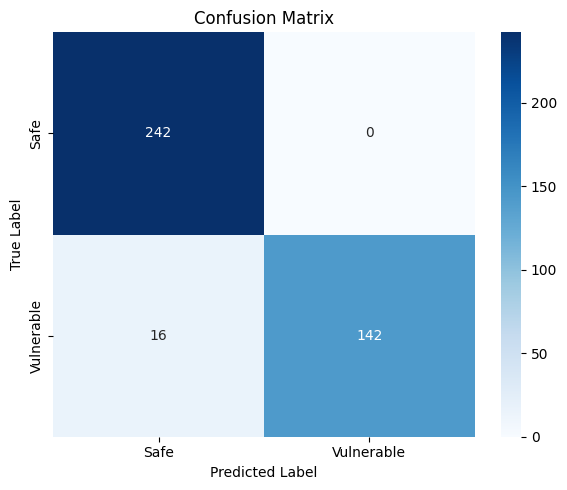

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

pred = trainer.predict(test_dataset)
preds = pred.predictions.argmax(axis=1)
cm = confusion_matrix(y_test, preds)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Safe", "Vulnerable"],
    yticklabels=["Safe", "Vulnerable"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
print("Train CWE:")
print(train_df['cwe_category'].value_counts())

print("\nTest CWE:")
print(test_df['cwe_category'].value_counts())

Train CWE:
cwe_category
CWE122_Heap_Based_Buffer_Overflow               204
CWE78_OS_Command_Injection                      162
CWE762_Mismatched_Memory_Management_Routines    151
CWE190_Integer_Overflow                         128
CWE134_Uncontrolled_Format_String               126
CWE121_Stack_Based_Buffer_Overflow              120
CWE191_Integer_Underflow                         77
Name: count, dtype: int64

Test CWE:
cwe_category
CWE23_Relative_Path_Traversal                                   79
CWE401_Memory_Leak                                              78
CWE127_Buffer_Underread                                         67
CWE36_Absolute_Path_Traversal                                   67
CWE590_Free_Memory_Not_on_Heap                                  64
CWE124_Buffer_Underwrite                                        62
CWE415_Double_Free                                              48
CWE789_Uncontrolled_Mem_Alloc                                   48
CWE194_Unexpected_Sign_Ext

In [1]:
df = pd.read_csv('juliet_sample_with_explanations_and_fixes.csv')
df['target'] = (df['label'] == 'vulnerable').astype(int)

# Define CWE categories for training, keeping the rest completely unseen for testing
train_cwes = [
    'CWE122_Heap_Based_Buffer_Overflow',
    'CWE762_Mismatched_Memory_Management_Routines',
    'CWE190_Integer_Overflow',
    'CWE134_Uncontrolled_Format_String',
    'CWE78_OS_Command_Injection',
    'CWE121_Stack_Based_Buffer_Overflow',
    'CWE23_Relative_Path_Traversal',
    'CWE197_Numeric_Truncation_Error',
    'CWE606_Unchecked_Loop_Condition',
    'CWE114_Process_Control',
    'CWE427_Uncontrolled_Search_Path_Element',
    'CWE761_Free_Pointer_Not_at_Start_of_Buffer',
    'CWE680_Integer_Overflow_to_Buffer_Overflow',
    'CWE319_Cleartext_Tx_Sensitive_Info',
    'CWE90_LDAP_Injection',
    'CWE404_Improper_Resource_Shutdown',
    'CWE256_Plaintext_Storage_of_Password',
]

train_df = df[df['cwe_category'].isin(train_cwes)].reset_index(drop=True)
test_df = df[~df['cwe_category'].isin(train_cwes)].reset_index(drop=True)

print(f'Train Set: {len(train_df)} samples {len(train_cwes)} categories')
print(f'Test Set: {len(test_df)} samples {test_df["cwe_category"].nunique()} *unseen* categories')

Train Set: 1134 samples 17 categories
Test Set: 866 samples 32 *unseen* categories


In [2]:
def structural_code_parser(code_snippet):
    # remove comments
    code_snippet = re.sub(r'/\*.*?\*/', '', code_snippet, flags=re.DOTALL)
    code_snippet = re.sub( r'//.*','',code_snippet)

    # remove Juliet identifiers
    code_snippet = re.sub(r'CWE\d+_[A-Za-z0-9_]+','FUNCTION',code_snippet)
    code_snippet = re.sub(r'\b(bad|good)\b', 'IDENTIFIER', code_snippet,flags=re.I)

    tokens = re.findall(r'\b\w+\b|[^\w\s]', code_snippet)

    keep = {'if','else','while','for', 'return', 'int', 'char', 'malloc','free', 'memcpy', 'strcpy', 'printf', 'system'}

    output=[]

    for t in tokens:
        if t in keep:
            output.append(t)
        elif t in ['+','-','*','/','=','%']:
            output.append(t)
        elif t.isdigit():
            output.append('<NUMBER>')
        elif t.isalpha():
            output.append('<IDENTIFIER>')
    return " ".join(output)


train_df['ast_text'] = train_df['code'].apply(structural_code_parser)
test_df['ast_text'] = test_df['code'].apply(structural_code_parser)

for x in test_df['ast_text'].head(20):
    if 'CWE' in x or 'bad' in x.lower() or 'good' in x.lower():
        print(x)

print(set(train_df['ast_text']) & set(test_df['ast_text']))

tokenizer = RobertaTokenizer.from_pretrained('microsoft/codebert-base')

{'<IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> else <IDENTIFIER> <IDENTIFIER> / <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> / <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> / <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> / <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> - <NUMBER> <IDENTIFIER> - <NUMBER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> int <IDENTIFIER> <IDENTIFIER> <NUMBER> <IDENTIFIER> <NUMBER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> else <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> char * <IDENTIFIER> <IDENTIFIER> = <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> <IDENTIFIER> int 

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [3]:
class CodeDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels

  def __getitem__(self, idx):
    item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels'] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)


train_enc = tokenizer(
    train_df['ast_text'].tolist(),
    truncation=True,
    padding='max_length',
    max_length=512,
)
test_enc = tokenizer(
    test_df['ast_text'].tolist(),
    truncation=True,
    padding='max_length',
    max_length=512,
)

train_dataset = CodeDataset(train_enc, train_df['target'].values)
test_dataset = CodeDataset(test_enc, test_df['target'].values)

In [4]:
def compute_metrics(pred):
  labels = pred.label_ids
  probs = (torch.nn.functional.softmax(torch.tensor(pred.predictions), dim=-1)[:, 1].numpy())

  precision, recall, thresholds = precision_recall_curve(labels, probs)
  f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
  best_idx = np.argmax(f1_scores)
  best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

  preds = (probs >= best_thresh).astype(int)

  return {
      'f1': f1_score(labels, preds, zero_division=0),
      'auroc': roc_auc_score(labels, probs),
      'precision': precision_score(labels, preds, zero_division=0),
      'recall': recall_score(labels, preds, zero_division=0),
      'best_threshold': float(best_thresh),
  }

In [5]:
model = RobertaForSequenceClassification.from_pretrained('microsoft/codebert-base', num_labels=2)

training_args = TrainingArguments(
    output_dir='./codebert_ast_results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    fp16=True,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  499MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=284, training_loss=0.659912431743783, metrics={'train_runtime': 321.6334, 'train_samples_per_second': 14.103, 'train_steps_per_second': 0.883, 'total_flos': 1193471747112960.0, 'train_loss': 0.659912431743783, 'epoch': 4.0})

Training Loss,Validation Loss,Epoch,F1,Auroc,Precision,Recall,Best Threshold
No log,0.664066,4,0.607862,0.616407,0.463450,0.883008,0.280666


Evaluation Metrics: {'eval_loss': 0.6640655994415283, 'eval_f1': 0.6078619367209971, 'eval_auroc': 0.6164065204133771, 'eval_precision': 0.46345029239766083, 'eval_recall': 0.883008356545961, 'eval_best_threshold': 0.28066566586494446}


Saved evaluation dashboard graph as 'cross_cwe_evaluation_dashboard.png'.


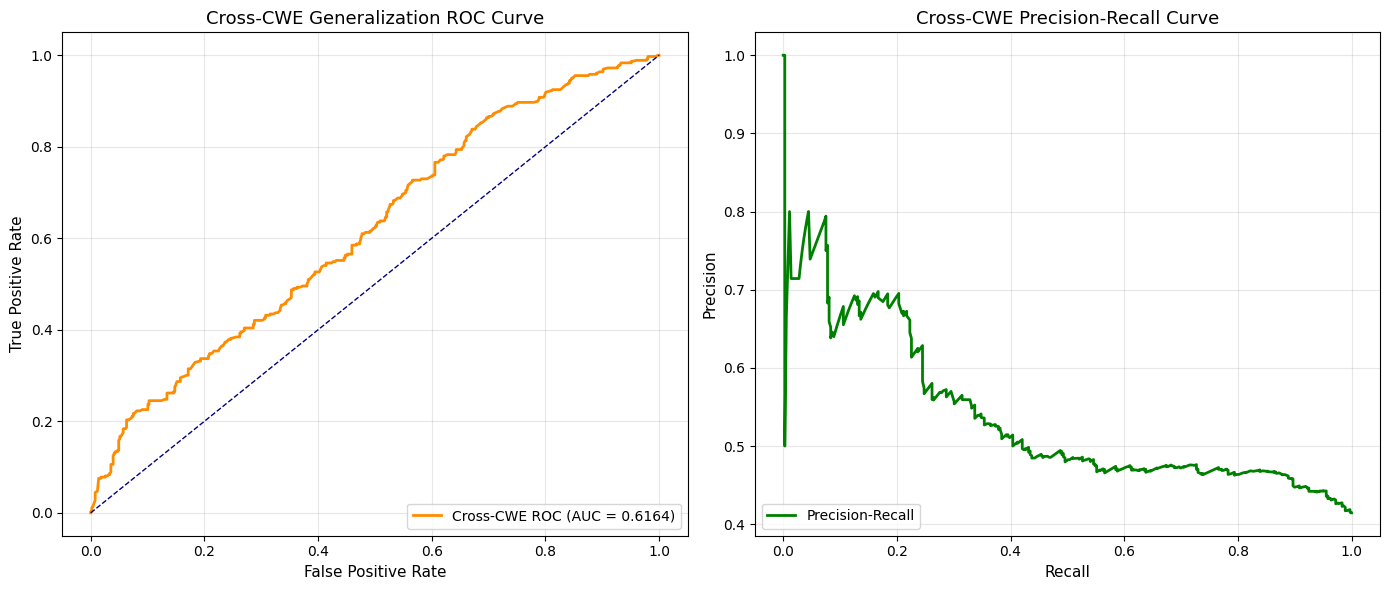

In [6]:
eval_results = trainer.evaluate()
print('Evaluation Metrics:', eval_results)

preds_output = trainer.predict(test_dataset)
test_probs = (torch.nn.functional.softmax(torch.tensor(preds_output.predictions), dim=-1)[:, 1].numpy())
test_labels = preds_output.label_ids

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fpr, tpr, _ = roc_curve(test_labels, test_probs)
auroc_val = roc_auc_score(test_labels, test_probs)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'Cross-CWE ROC (AUC = {auroc_val:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[0].set_title('Cross-CWE Generalization ROC Curve', fontsize=13)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

prec_arr, rec_arr, _ = precision_recall_curve(test_labels, test_probs)
axes[1].plot(rec_arr, prec_arr, color='green', lw=2, label='Precision-Recall')
axes[1].set_title('Cross-CWE Precision-Recall Curve', fontsize=13)
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cross_cwe_evaluation_dashboard.png', dpi=300)
print(
    "Saved evaluation dashboard graph as 'cross_cwe_evaluation_dashboard.png'."
)
plt.show()